In [1]:
import numpy as np
import torch 
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev
from scipy import interpolate

import sys
sys.path.append('/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE')

from data_utils.pv_utils import *

In [2]:
df = torch.load("/home/gridsan/tmackey/cdvae/scripts/XRD_CDVAE/RRUFF/noise_analysis_data/RRUFF_data_for_noise_analysis_filtered.pt")

In [3]:
df['filename'].iloc[0]

'Beryl__R050347-1__Powder__Xray_Data_XY_RAW__1514.txt'

In [4]:
test_xrd = {}
for i in range(len(df)): 
    test_xrd[df['names'].iloc[i]] = torch.tensor(df['xrd'].iloc[i][:, 1][:8500]).unsqueeze(0)

In [5]:
#select only [:8500] of the values in test_xrd
for key in test_xrd.keys():
    test_xrd[key] = test_xrd[key][:,:8500]

In [6]:
def background_subtraction(x_data, y_data, cheb_order = 5, std_mult = 10, tolerance = 1e-8):
    def exclude_outliers(x, y, fit_y, std_mult = 3):
        y_bs = y - fit_y
        mean = np.mean(y_bs)
        std = np.std(y_bs)
        outlier_mask = (y_bs < mean + std * std_mult) & (y_bs > mean - std * std_mult)
        std_masked = y_bs[outlier_mask]
        x_data = x[outlier_mask]
        y_data = y[outlier_mask]

        return x_data, y_data, std_masked

    def chebyshev_fit(x, *coeffs):
        # Use the first 3 Chebyshev polynomials of the first kind
        return sum(c * chebyshev.chebval(x, [0] * i + [1]) for i, c in enumerate(coeffs))

    y_data = y_data / np.max(y_data)
    
    x_data_background = x_data
    background = y_data
    fit_y = [0] * len(background)
    initial_guess = [0] * cheb_order
    counter = 0
    
    while abs(sum(fit_y - background)/len(fit_y)) > tolerance and counter < 20:
        popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)
        fit_y = chebyshev_fit(x_data_background, *popt)
        x_data_background, background, y_bs = exclude_outliers(x_data_background, background, fit_y, std_mult=3)
        fit_y = chebyshev_fit(x_data_background, *popt)
        # plot the background
        # plt.plot(x_data_background, background)
        # plt.plot(x_data_background, fit_y)
        # plt.show()
        counter += 1
    
    #background subtraction & following clip
    background = adaption.background_subtraction(x_data_background, background, 100)

    if counter == 20:
        print("This model may perform poorly on data with a complicated background")
        
    popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)

    # # Generate fitted y values
    # fit_y = chebyshev_fit(x_data, *popt)

    # Subtract fitted y values from data
    y_data = adaption.background_subtraction(x_data, y_data, 100)

    #rescale the background by the y data max 
    background = background / np.max(y_data)

    #find the residual to 0 after application of mask
    above_zero = background - np.zeros(len(background))

    return y_data, fit_y, y_bs, x_data_background, background, above_zero

In [7]:
#print the shapes of all the xrd patterns
for key in test_xrd.keys():
    print(key, test_xrd[key].shape)

Beryl torch.Size([1, 8500])
Triplite torch.Size([1, 8500])
Colemanite torch.Size([1, 8500])
Norbergite torch.Size([1, 8500])
Caryochroite torch.Size([1, 8500])
Destinezite torch.Size([1, 8500])
Manganogrunerite torch.Size([1, 8500])
Hastingsite torch.Size([1, 8500])
Pyromorphite torch.Size([1, 8500])
Satterlyite torch.Size([1, 8500])
Laumontite torch.Size([1, 8500])
Zinkenite torch.Size([1, 8500])
Actinolite torch.Size([1, 8500])
Elpidite torch.Size([1, 8500])
Ephesite torch.Size([1, 8500])
Celsian torch.Size([1, 8500])
Cancrinite torch.Size([1, 8500])
Schorlomite torch.Size([1, 8500])
Barysilite torch.Size([1, 8500])
Harmotome torch.Size([1, 8500])
Galkhaite torch.Size([1, 8500])
Leightonite torch.Size([1, 8500])
Aurichalcite torch.Size([1, 8500])
Burkeite torch.Size([1, 8500])
Botryogen torch.Size([1, 8500])
Leucophanite torch.Size([1, 8500])
Trona torch.Size([1, 8500])
Yugawaralite torch.Size([1, 8500])
Chrysoberyl torch.Size([1, 8500])
Barrerite torch.Size([1, 8500])
Bahianite torc

Beryl


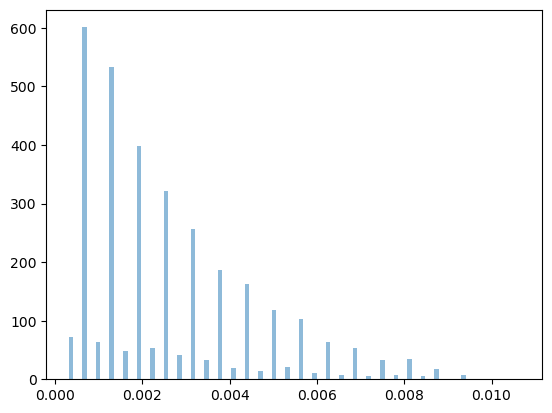

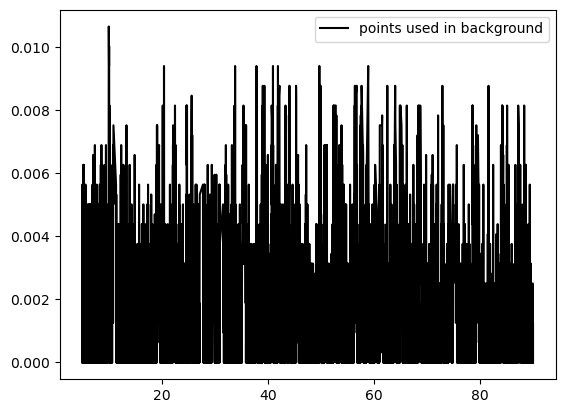

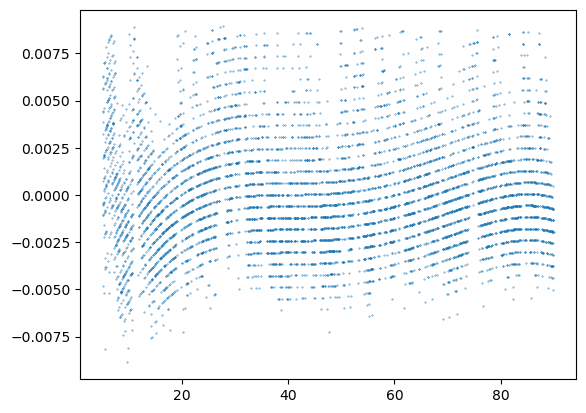

Triplite


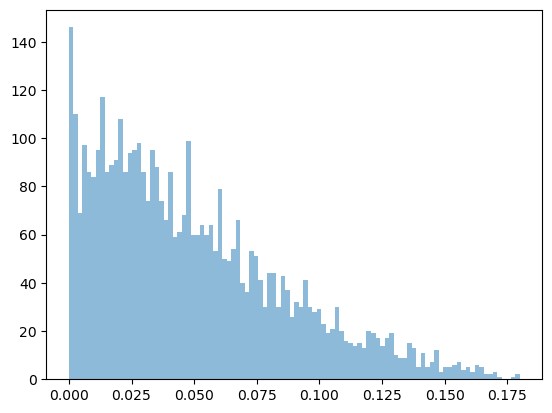

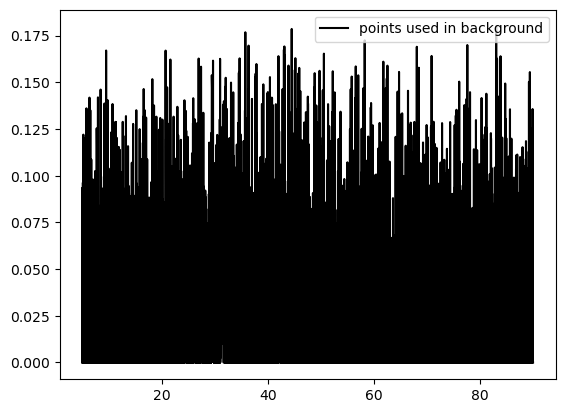

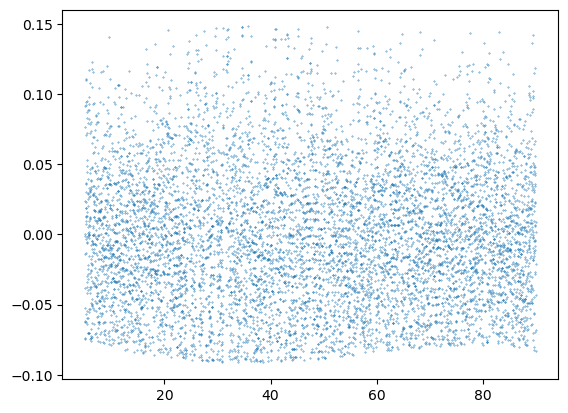

Colemanite


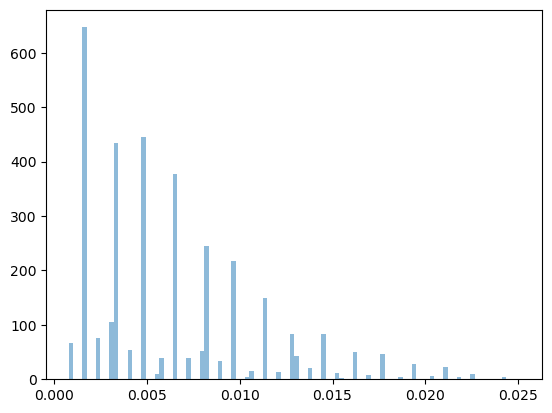

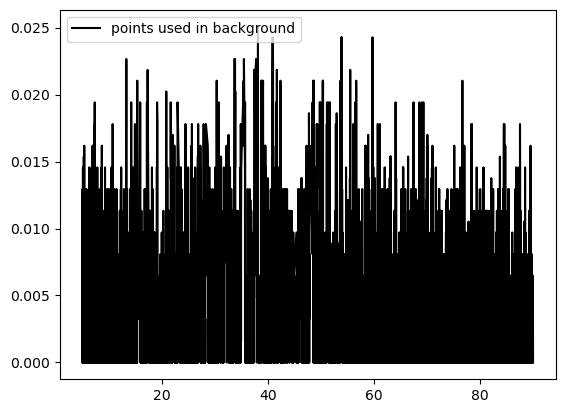

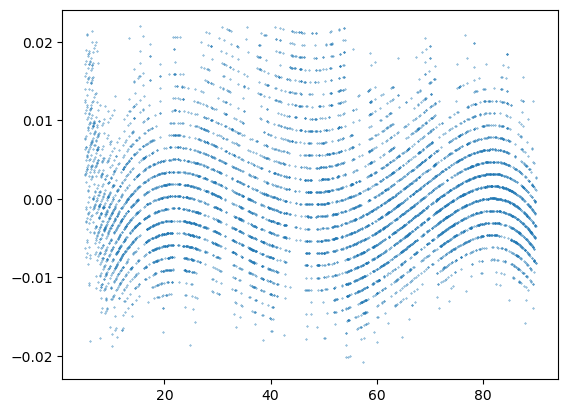

Norbergite


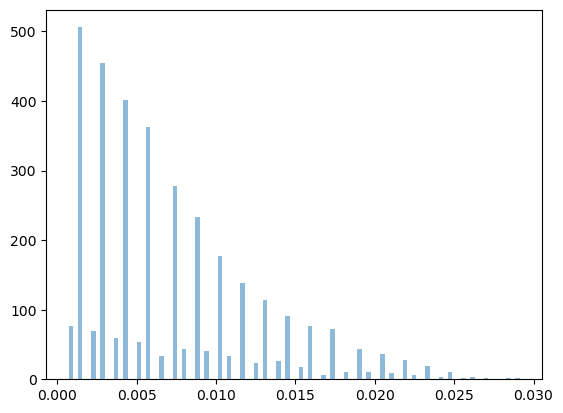

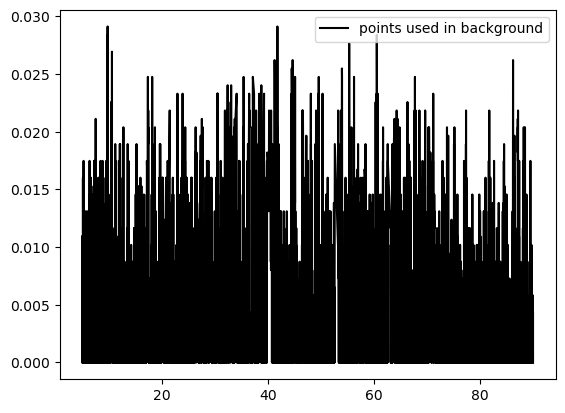

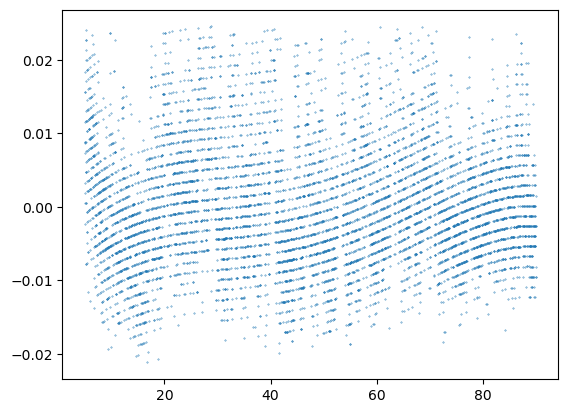

Caryochroite


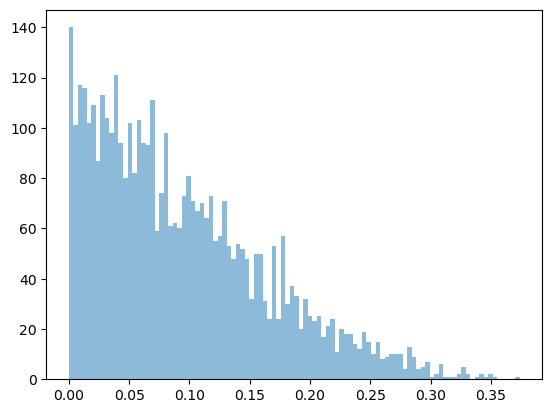

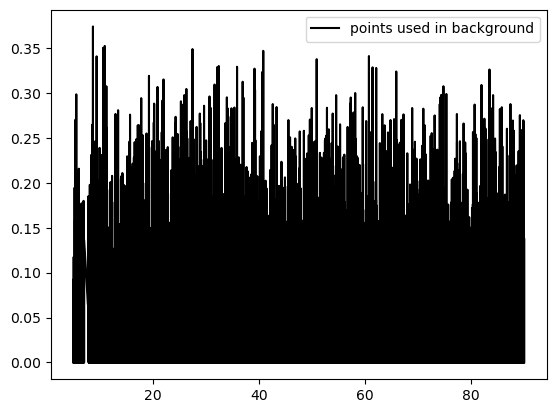

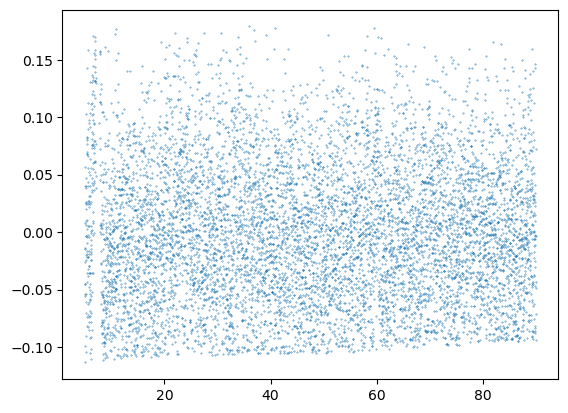

Destinezite


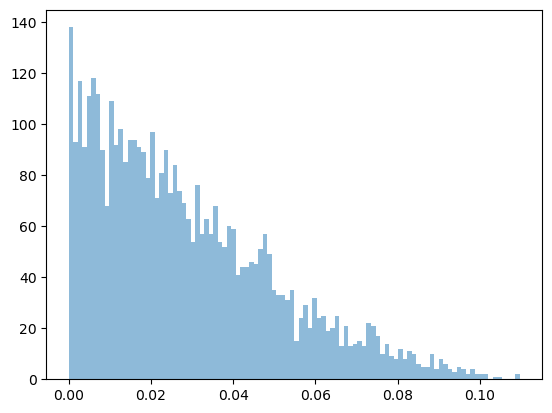

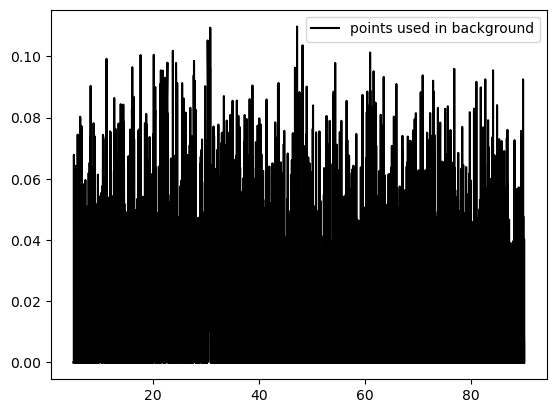

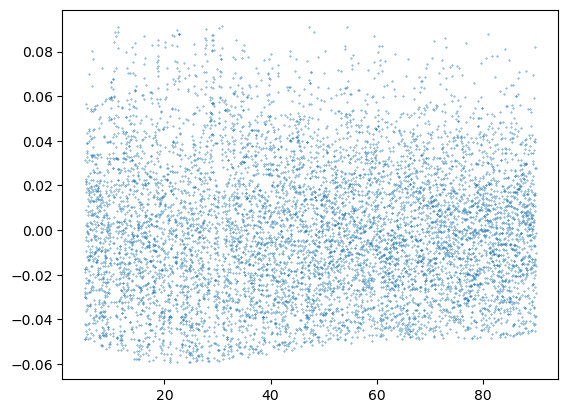

Manganogrunerite


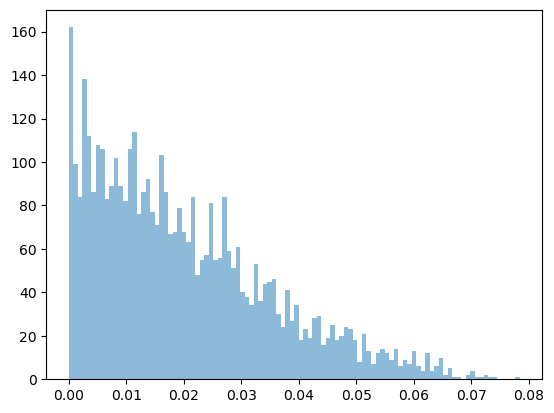

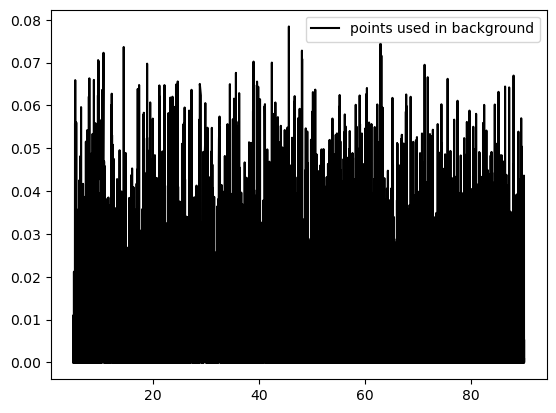

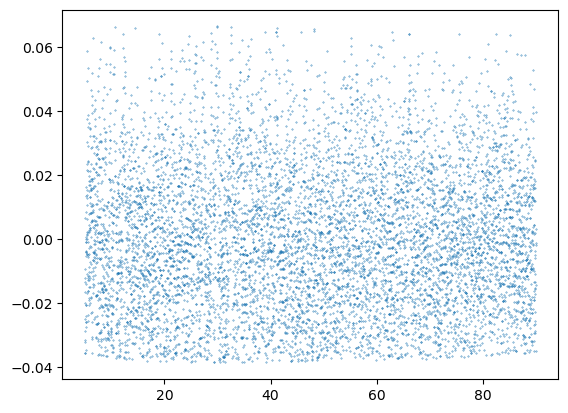

Hastingsite


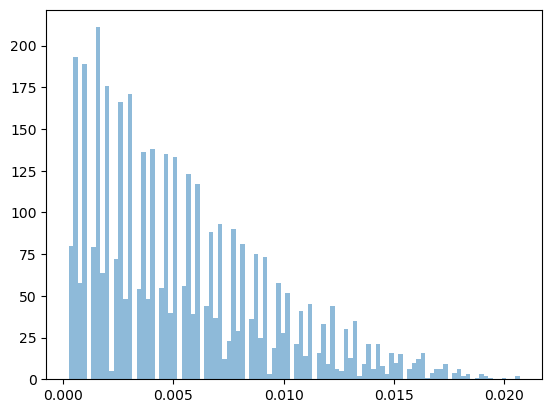

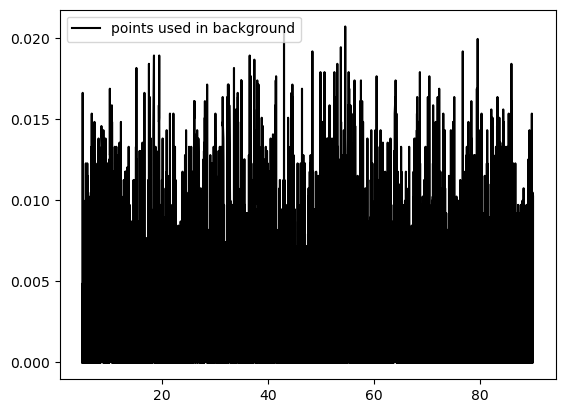

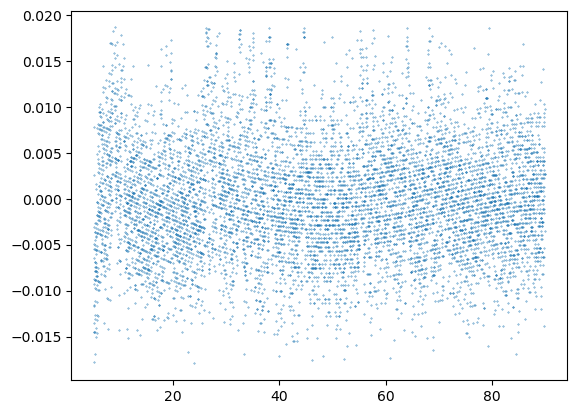

Pyromorphite


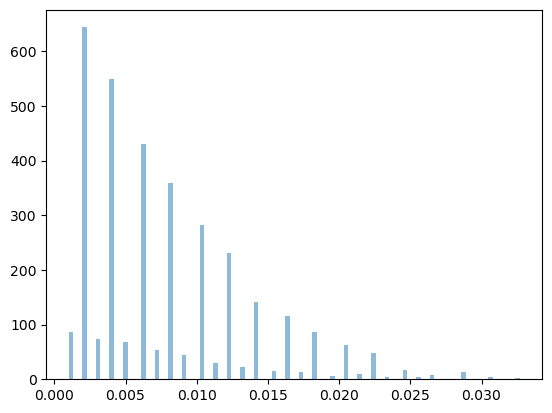

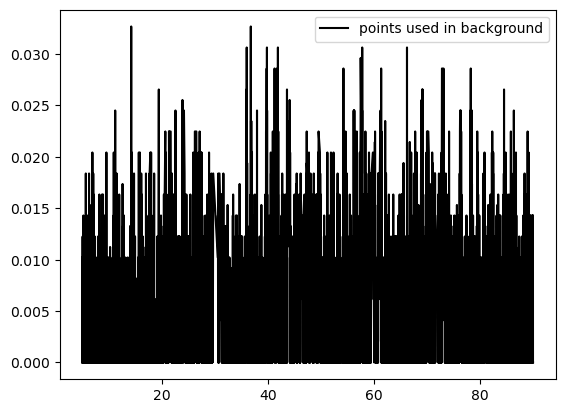

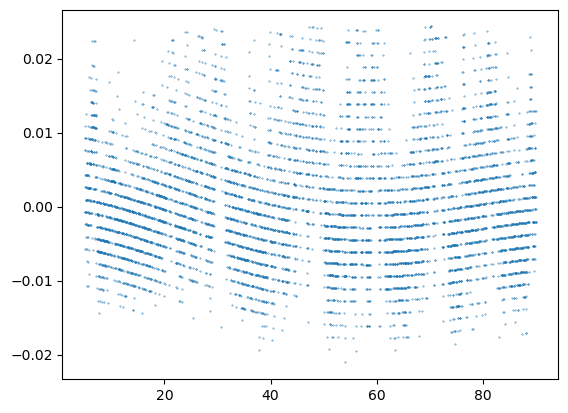

Satterlyite


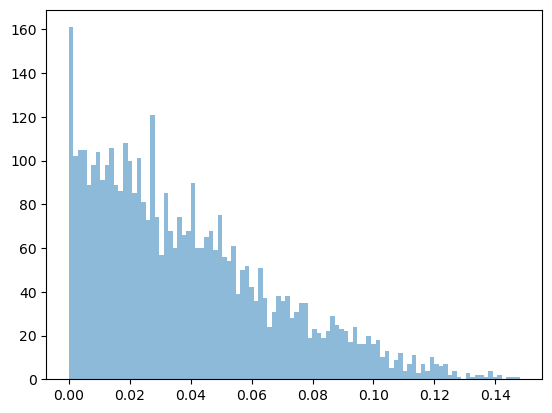

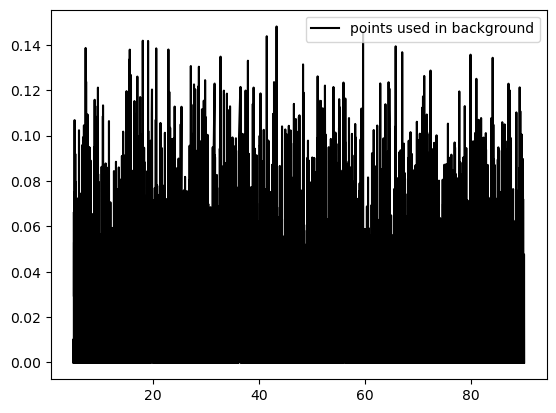

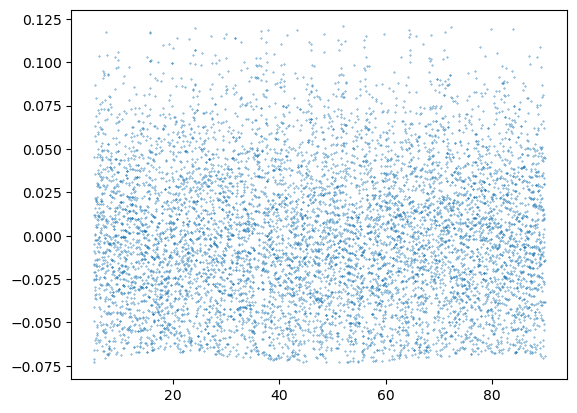

In [8]:
list_of_errors = []
niter = len(test_xrd.keys())
for i in range(10):
    #try: 
    #implement background subtraction
    print(list(test_xrd.keys())[i])
    x_values = np.arange(5, 90, 0.01)
    y_values = test_xrd[list(test_xrd.keys())[i]][0].numpy()
    y_values_subtracted, background_fit, y_bs, x_data_background, background, above_zero = background_subtraction(x_values, y_values)
    plt.hist(above_zero[above_zero != 0], bins = 100, alpha = 0.5)
    plt.show()
    
    #plt.plot(x_values, y_values, label='original', color = "blue", alpha = 0.5)
    #plt.plot(x_values, y_values_subtracted, label='background subtracted', color = "orange", alpha = 0.5)
    #plt.plot(x_values, background_fit, label='background', color = "green", alpha = 0.5)
    #plot points used in the background 
    plt.plot(x_data_background, background, color = 'black', label='points used in background')
    plt.legend()
    plt.show()
        
    # except Exception as e:
    #     print(e)
    #     list_of_errors.append(i)
    #     #plot 
    #     # plt.plot(x_values, y_values, label='original')
    #     # plt.plot(x_values, y_values_subtracted, label='background subtracted')
    #     # plt.plot(x_values, background_fit, label='background')
    #     # #plot points used in the background 
    #     # plt.plot(x_data_background, background, color = 'black', label='points used in background')
    #     # plt.legend()
    #     # plt.show()
        
    #make a graph of y_bs vs x_data_background
    plt.scatter(x_data_background, y_bs, s = 0.1)
    plt.show()

operands could not be broadcast together with shapes (8500,) (3600,) 
operands could not be broadcast together with shapes (8500,) (1760,) 
operands could not be broadcast together with shapes (8500,) (1499,) 
operands could not be broadcast together with shapes (8500,) (1550,) 
operands could not be broadcast together with shapes (8500,) (1421,) 
operands could not be broadcast together with shapes (8500,) (1951,) 
operands could not be broadcast together with shapes (8500,) (7501,) 
This model may perform poorly on data with a complicated background
operands could not be broadcast together with shapes (8500,) (1234,) 
operands could not be broadcast together with shapes (8500,) (1960,) 
operands could not be broadcast together with shapes (8500,) (1512,) 
operands could not be broadcast together with shapes (8500,) (1501,) 


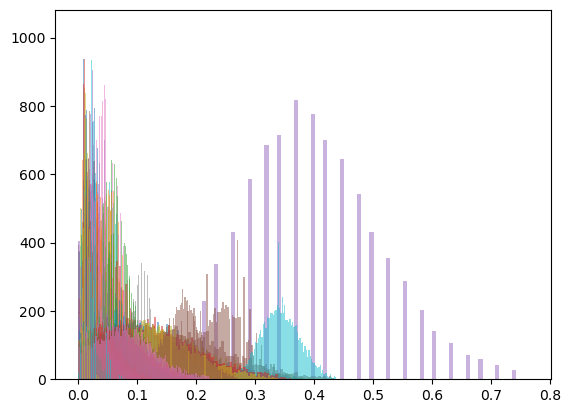

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# Lists to store the parameters
a_params = []
loc_params = []
scale_params = []
list_of_errors = []
niter = len(test_xrd.keys())

for i in range(niter):
    try: 
        # Background subtraction
        x_values = np.arange(5, 90, 0.01)
        y_values = test_xrd[list(test_xrd.keys())[i]][0].numpy()

        # #plot the original data
        # plt.plot(x_values, y_values, label='original')
        # plt.show()

        y_values_subtracted, background_fit, y_bs, x_data_background, background, above_zero = background_subtraction(x_values, y_values)

        # # Plot histogram
        hist_data, bins, _ = plt.hist(above_zero, bins=100, alpha=0.5, label='Noise Histogram')

        # Fit a Gamma distribution with loc set to 0 
        a, loc, scale = gamma.fit(above_zero, loc=0)
        pdf_gamma = gamma.pdf(bins, a, loc, scale)

        # Normalize the Gamma distribution to match the histogram
        pdf_gamma_normalized = pdf_gamma * (bins[1] - bins[0]) * len(above_zero)

        # # Plot Gamma fit
        # plt.plot(bins, pdf_gamma_normalized, label='Gamma Fit', color='red')

        # plt.show()

        # # Add legend and labels
        # plt.legend()
        # plt.xlabel('Noise Levels')
        # plt.ylabel('Frequency')
        # plt.title(f'Gamma Fit for Dataset {i}')
        # plt.show()

        # Store the parameters
        a_params.append(a)
        loc_params.append(loc)
        scale_params.append(scale)
    except Exception as e:
        print(e)
        #save the index
        list_of_errors.append(i)
        continue


[1215.055 1191.844 1189.688 1188.345 1213.338 1179.491 1154.476 1208.73
 1226.716 1199.448]


ValueError: x and y must have same first dimension, but have shapes (8500,) and (3600,)

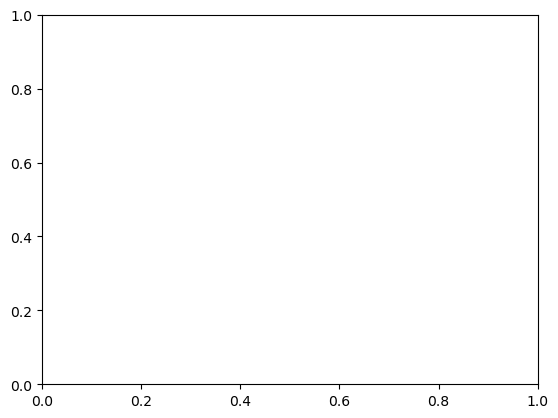

In [22]:
#plot the bad fits
for i in list_of_errors:
    # Background subtraction
    x_values = np.arange(5, 90, 0.01)
    y_values = test_xrd[list(test_xrd.keys())[i]][0].numpy()
    print(y_values[:10])

    #plot trhe original data
    plt.plot(x_values, y_values, label='original')
    plt.show()

    # y_values_subtracted, background_fit, y_bs, x_data_background, background = background_subtraction(x_values, y_values)

    # # Plot histogram
    # hist_data, bins, _ = plt.hist(y_bs, bins=100, alpha=0.5, label='Noise Histogram')

    # # Fit a Gamma distribution with loc set to 0 
    # a, loc, scale = gamma.fit(y_bs, loc=0)
    # pdf_gamma = gamma.pdf(bins, a, loc, scale)

    # # Normalize the Gamma distribution to match the histogram
    # pdf_gamma_normalized = pdf_gamma * (bins[1] - bins[0]) * len(y_bs)

    # # Plot Gamma fit
    # plt.plot(bins, pdf_gamma_normalized, label='Gamma Fit', color='red')

    # # Add legend and labels
    # plt.legend()
    # plt.xlabel('Noise Levels')
    # plt.ylabel('Frequency')
    # plt.title(f'Gamma Fit for Dataset {i}')
    # plt.show()

In [23]:
# Convert lists to numpy arrays
a_params = np.array(a_params)
scale_params = np.array(scale_params)

#remove a_params greater than 10 
a_params_filtered = a_params[a_params < 10]
scale_params_filtered = scale_params[a_params < 10]

scale_params_filtered_2 = scale_params_filtered[scale_params_filtered < 1]
a_params_filtered_2 = a_params_filtered[scale_params_filtered < 1]


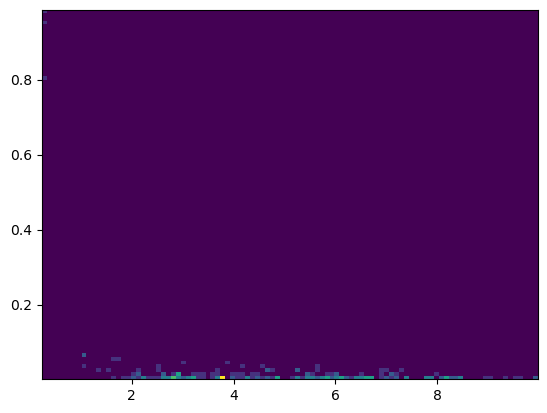

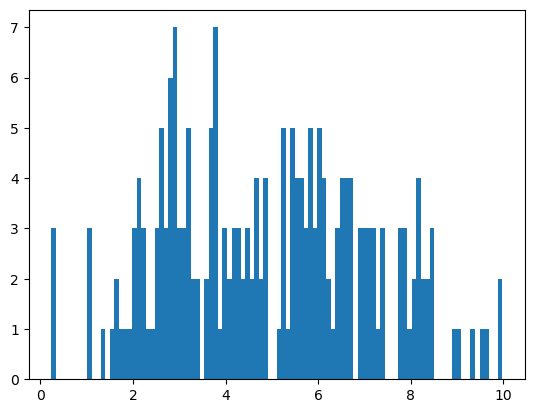

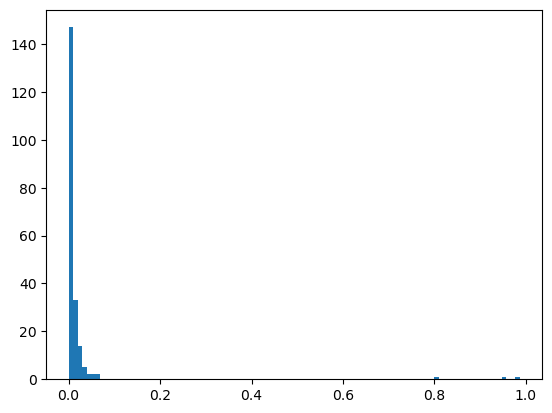

In [24]:
#plot a 2d histogram of a_params vs scale_params
plt.hist2d(a_params_filtered_2, scale_params_filtered_2, bins = 100)
plt.show()

#plot individual histograms of a_params and scale_params
plt.hist(a_params_filtered_2, bins = 100)
plt.show()

plt.hist(scale_params_filtered_2, bins = 100)
plt.show()


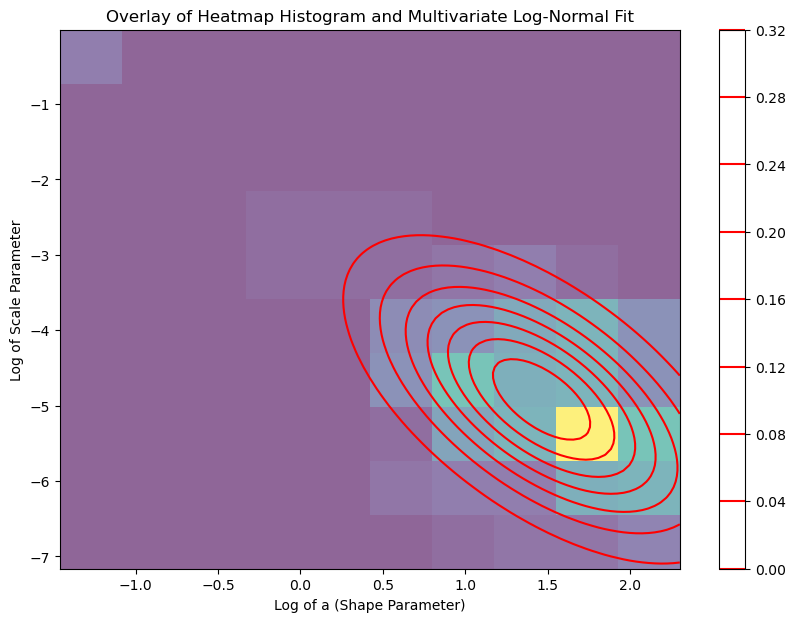

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Assuming a_params_filtered_2 and scale_params_filtered_2 are your filtered data

# Log-transform the data
log_a = np.log(a_params_filtered_2)
log_scale = np.log(scale_params_filtered_2)

# Combine the log-transformed data
log_data = np.vstack([log_a, log_scale]).T

# Fit a multivariate normal distribution to the log-transformed data
mean, cov = np.mean(log_data, axis=0), np.cov(log_data, rowvar=False)

# Create an instance of a multivariate normal distribution
mvn = multivariate_normal(mean, cov)

# Create a grid for visualization
x, y = np.mgrid[min(log_a):max(log_a):100j, min(log_scale):max(log_scale):100j]
pos = np.dstack((x, y))

# Evaluate the multivariate normal distribution on the grid
z = mvn.pdf(pos)

# Plotting
plt.figure(figsize=(10, 7))

# Plot the heatmap histogram of the log-transformed data
plt.hist2d(log_a, log_scale, bins=10, cmap='viridis', alpha=0.6)

# Overlay the contour plot of the fitted distribution
plt.contour(x, y, z, colors='r')

plt.colorbar()
plt.title('Overlay of Heatmap Histogram and Multivariate Log-Normal Fit')
plt.xlabel('Log of a (Shape Parameter)')
plt.ylabel('Log of Scale Parameter')
plt.show()


Mean of the fitted distribution: [ 1.4621024  -4.91674415]
Covariance matrix of the fitted distribution: [[ 0.34926355 -0.38512762]
 [-0.38512762  1.14459871]]


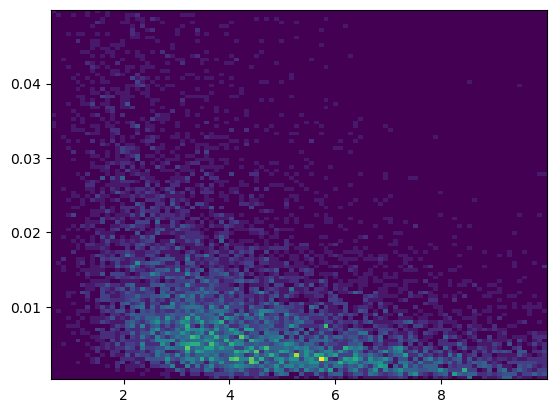

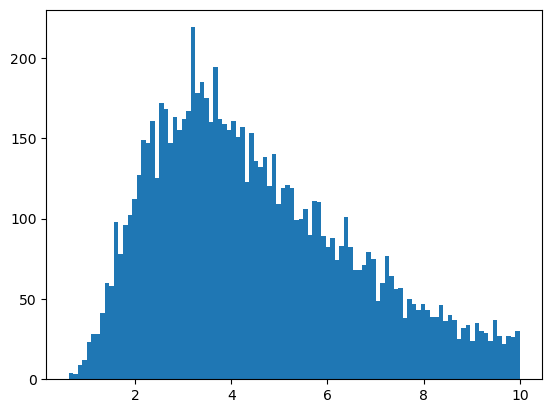

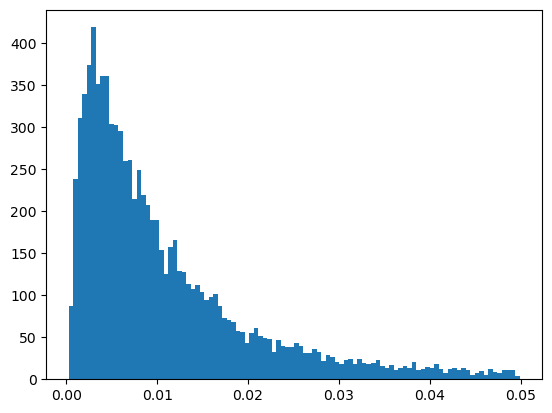

In [26]:

# Combine the log-transformed data
log_data = np.vstack([log_a, log_scale]).T

# Fit a multivariate normal distribution to the log-transformed data
mean, cov = np.mean(log_data, axis=0), np.cov(log_data, rowvar=False)

# Print the fitted distribution parameters
print("Mean of the fitted distribution:", mean)
print("Covariance matrix of the fitted distribution:", cov)

# Create an instance of a multivariate normal distribution
mvn = multivariate_normal(mean, cov)

# Sample points from the distribution
num_samples = 10000  # You can change this to your desired number of samples
samples = mvn.rvs(size=num_samples)

#remove any samples with values in the second column greater than ln(0.05)
#remove any samples with values in the first column greater than ln(10)
samples_filtered = samples[samples[:,1] < np.log(0.05)]
samples_filtered = samples_filtered[samples_filtered[:,0] < np.log(10)]

#calculate the exponentials of the samples
samples_exp = np.exp(samples_filtered)

# Plot 2d histogram of the exp samples
plt.hist2d(samples_exp[:, 0], samples_exp[:, 1], bins=100)
plt.show()

#plot individual histograms of the exp samples
plt.hist(samples_exp[:, 0], bins=100)
plt.show()

plt.hist(samples_exp[:, 1], bins=100)
plt.show()


Looks pretty accurate.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import gamma
import torch

In [20]:
mean = np.array([1.06709083, -5.39670499])
cov = np.array([[0.19984825, 0.14809546],
                [0.14809546, 1.31019437]])

# Create an instance of a multivariate normal distribution
mvn = multivariate_normal(mean, cov)

# Sample points from the distribution
num_samples = 500  # You can change this to your desired number of samples
samples = mvn.rvs(size=num_samples)

#remove any samples with values in the second column greater than ln(0.05)
#remove any samples with values in the first column greater than ln(10)
samples_filtered = samples[samples[:,1] < np.log(0.05)]
samples_filtered = samples_filtered[samples_filtered[:,0] < np.log(10)]

#take the first 256 
samples_filtered = samples_filtered[:256]

#calculate the exponentials of the samples
samples_exp = np.exp(samples_filtered)

a = samples_exp[:, 0]
scale = samples_exp[:, 1]
#make a gamma distribution for each a and scale
gamma_samples = []
for i in range(len(a)):
    gamma_samples.append(gamma(a = a[i], scale = scale[i], loc = 0).rvs(8500))

gamma_samples = np.stack(gamma_samples)
gamma_samples = torch.tensor(gamma_samples)

#unsqueeze at the 1st dimension
gamma_samples = gamma_samples.unsqueeze(0)


In [21]:
gamma_samples.shape

torch.Size([1, 256, 8500])

In [22]:
import numpy as np
import pandas as pd
import torch

In [27]:
gamma_samples.shape

torch.Size([1, 256, 8500])

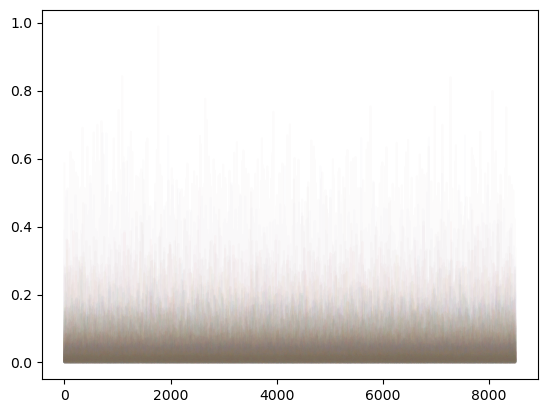

In [28]:
for i in range(200): 
    plt.plot(gamma_samples[0][i], alpha = 0.02)

In [33]:
gamma_samples[0][1].shape

torch.Size([8500])

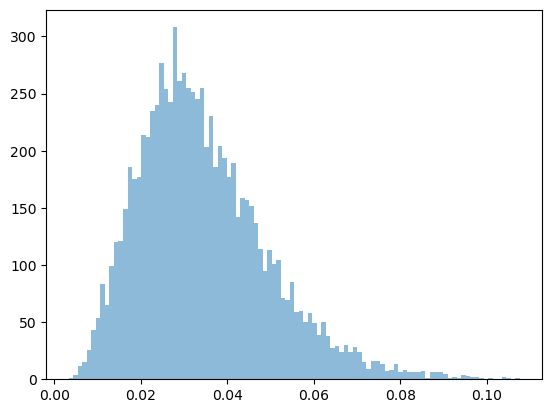

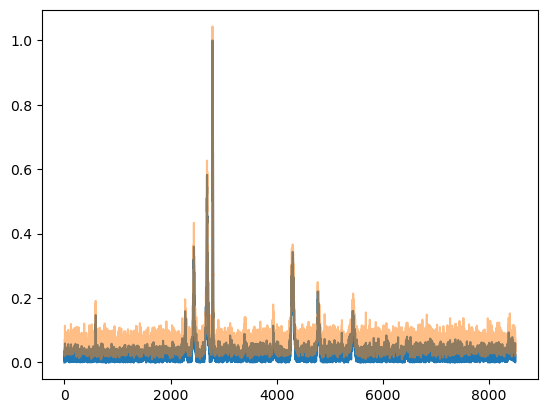

In [38]:
#take random samples from each gamma distribution and plot them
i = 3
plt.hist(gamma_samples[0][i], bins = 100, alpha = 0.5)
plt.show()

plt.plot(test_xrd[list(test_xrd.keys())[i]][0].numpy(), label='original')
plt.plot(test_xrd[list(test_xrd.keys())[i]][0].numpy() + gamma_samples[0][i].numpy(), label='with noise', alpha = 0.5)
plt.show()
    